# EDA Diagnóstico — TCC Dataset

Diagnóstico sistemático de **12 categorias de problemas** que podem interferir na qualidade do modelo StockEmbedder.

| # | Categoria | Risco |
|---|-----------|-------|
| 1 | Look-ahead via winsorização no dataset completo | 🔴 Alto |
| 2 | Staleness de fundamentais (forward-fill excessivo) | 🔴 Alto |
| 3 | Outliers em retornos (não windsorisados) | 🟡 Médio |
| 4 | Survivorship bias | 🟡 Médio |
| 5 | Distribution shift train → val → test | 🟡 Médio |
| 6 | Contaminação por zero-fill (NaN → 0) | 🔴 Alto |
| 7 | Patologias das features compostas (FCF Yield / FCF/Dívida) | 🟡 Médio |
| 8 | Dupla exposição ON/PN (XXXX3 + XXXX4) | 🟡 Médio |
| 9 | Correlação entre features / redundância | 🟡 Médio |
| 10 | Variância cross-sectional vs temporal | 🟡 Médio |
| 11 | Esparsidade do painel | 🟢 Baixo |
| 12 | Qualidade da integração de dados | 🟢 Baixo |

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

# ── Locate processing/ directory so config.py is importable ──────────────────
_cwd = Path.cwd()
_proc_dir = _cwd if (_cwd / "config.py").exists() else _cwd / "processing"
if not (_proc_dir / "config.py").exists():
    raise RuntimeError(f"Cannot find config.py. CWD={_cwd}")
if str(_proc_dir) not in sys.path:
    sys.path.insert(0, str(_proc_dir))

from config import (
    CLEANED, FEATURES, PARQUETS, RAW_ECO,
    TRAIN_END, VAL_END, MIN_DATE, FUNDAMENTAL_FILES,
    FCF_PATH, DIVIDA_TOTAL_PATH, MKTCAP_PATH,
)
from io_utils import read_economatica_wide

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 4)})
sns.set_theme(style="whitegrid", palette="muted")

# ── Period masks (applied to any df with a 'date' column) ────────────────────
TRAIN_END_TS    = pd.Timestamp(TRAIN_END)
VAL_END_TS      = pd.Timestamp(VAL_END)
MIN_DATE_TS     = pd.Timestamp(MIN_DATE)

def period_label(date: pd.Timestamp) -> str:
    if date <= TRAIN_END_TS:
        return "train"
    if date <= VAL_END_TS:
        return "val"
    return "test"

print("Config loaded. Paths:")
print(f"  CLEANED  = {CLEANED}")
print(f"  FEATURES = {FEATURES}")
print(f"  PARQUETS = {PARQUETS}")

Config loaded. Paths:
  CLEANED  = C:\Users\Diego Azenha\Documents\Python Projects\TCC Data Cleaning\cleaned
  FEATURES = C:\Users\Diego Azenha\Documents\Python Projects\TCC Data Cleaning\features
  PARQUETS = C:\Users\Diego Azenha\Documents\Python Projects\TCC Data Cleaning\parquets


In [2]:
# ── Load all datasets used across multiple diagnostics ───────────────────────
print("Loading parquets …")

prices       = pd.read_parquet(CLEANED  / "prices.parquet")
x_ts         = pd.read_parquet(PARQUETS / "x_ts.parquet")
x_static     = pd.read_parquet(PARQUETS / "x_static.parquet")
returns_raw  = pd.read_parquet(FEATURES / "returns.parquet")
fund_ffill   = pd.read_parquet(FEATURES / "fundamentals_ffill.parquet")
fcf_div      = pd.read_parquet(FEATURES / "fcf_divida_ffill.parquet")
fcf_yield_df = pd.read_parquet(FEATURES / "fcf_yield.parquet")
idx_returns  = pd.read_parquet(FEATURES / "index_returns.parquet")
mkt_idx      = pd.read_parquet(CLEANED  / "market_indices.parquet")

with open(PARQUETS / "normalization_stats.json") as f:
    norm_stats = json.load(f)

FEATURE_COLS  = norm_stats["feature_order"]        # list of 41 features
FUND_COLS     = [v[1] for v in FUNDAMENTAL_FILES.values()]
COMPOSITE_COLS = ["fcf_divida", "fcf_yield"]
IDX_COLS      = [c for c in FEATURE_COLS if c not in ["return"] + FUND_COLS + COMPOSITE_COLS]

# Add period column to x_ts
x_ts["period"] = x_ts["date"].apply(period_label)

print(f"\nDataset overview:")
print(f"  prices       : {prices.shape}       | {prices['ticker'].nunique()} tickers")
print(f"  x_ts         : {x_ts.shape}   | {x_ts['ticker'].nunique()} tickers, {x_ts['date'].nunique()} dates")
print(f"  x_static     : {x_static.shape}")
print(f"  returns_raw  : {returns_raw.shape}")
print(f"  fund_ffill   : {fund_ffill.shape}")
print(f"  FEATURE_COLS : {len(FEATURE_COLS)} features ({len(IDX_COLS)} idx, {len(FUND_COLS)} fund, {len(COMPOSITE_COLS)} composite)")
print(f"\n  Train  : {MIN_DATE} → {TRAIN_END}")
print(f"  Val    : {TRAIN_END} → {VAL_END}")
print(f"  Test   : {VAL_END} → present")

Loading parquets …

Dataset overview:
  prices       : (1739547, 3)       | 975 tickers
  x_ts         : (1738572, 44)   | 956 tickers, 5259 dates
  x_static     : (956, 12)
  returns_raw  : (1738572, 3)
  fund_ffill   : (1739547, 11)
  FEATURE_COLS : 41 features (29 idx, 9 fund, 2 composite)

  Train  : 2005-01-03 → 2018-12-31
  Val    : 2018-12-31 → 2022-12-31
  Test   : 2022-12-31 → present


---
## Cat 1 — Look-Ahead via Winsorização

`02_clean_fundamentals.py` e `05b_feature_composite.py` calculam bounds p1/p99 sobre **todos os dados** (treino + val + test). 
Isso vaza distribuições futuras para os limites de clipping aplicados ao período de treino.

**Diagnóstico**: re-calcular bounds com dados apenas do período de treino e comparar com os bounds reais usados.
Se o clipping no treino for sistematicamente diferente dos bounds "puros de treino", há leakage.

In [3]:
# ── Cat 1a: Winsorization look-ahead check ───────────────────────────────────
# For each fundamental in cleaned/, compare:
#   full-sample p1/p99 vs train-only p1/p99
# If they differ significantly, the cleaning step contaminated train observations.

rows = []
for name, (_, col) in FUNDAMENTAL_FILES.items():
    df = pd.read_parquet(CLEANED / f"{name}.parquet")

    # Full-sample bounds (as used by the pipeline)
    full_p1  = df[col].quantile(0.01)
    full_p99 = df[col].quantile(0.99)

    # Train-only bounds
    train_df = df[df["date"] <= TRAIN_END_TS]
    if len(train_df) == 0:
        continue
    train_p1  = train_df[col].quantile(0.01)
    train_p99 = train_df[col].quantile(0.99)

    # How many train observations were clipped differently with full-sample bounds?
    # i.e. values that are between train_p1 and full_p1  (or p99 equivalent)
    n_train = len(train_df)
    n_clipped_low  = ((train_df[col] < train_p1) & (train_df[col] >= full_p1)).sum()
    n_clipped_high = ((train_df[col] > train_p99) & (train_df[col] <= full_p99)).sum()
    n_excess_clip  = n_clipped_low + n_clipped_high  # obs clipped by full but not by train bounds

    # Relative shift of bounds
    range_full  = full_p99 - full_p1
    shift_low   = abs(full_p1  - train_p1)  / (abs(train_p1)  + 1e-9)
    shift_high  = abs(full_p99 - train_p99) / (abs(train_p99) + 1e-9)

    rows.append(dict(
        feature      = col,
        full_p1      = round(full_p1, 4),
        train_p1     = round(train_p1, 4),
        shift_p1_pct = round(100 * shift_low, 2),
        full_p99     = round(full_p99, 4),
        train_p99    = round(train_p99, 4),
        shift_p99_pct= round(100 * shift_high, 2),
        n_train      = n_train,
        n_excess_clip= int(n_excess_clip),
        pct_excess   = round(100 * n_excess_clip / n_train, 3),
    ))

winsor_df = pd.DataFrame(rows)
print("=== Winsorization Look-Ahead Check ===")
print("(shift_p1/p99_pct = how much the bound moved when restricting to train-only)")
print()
display(winsor_df.sort_values("shift_p99_pct", ascending=False))

# Flag features where bound shifted > 5%
flagged = winsor_df[(winsor_df["shift_p1_pct"] > 5) | (winsor_df["shift_p99_pct"] > 5)]
print(f"\n⚠  Features with >5% bound shift: {len(flagged)} / {len(winsor_df)}")
if len(flagged):
    display(flagged[["feature","shift_p1_pct","shift_p99_pct","n_excess_clip","pct_excess"]])

=== Winsorization Look-Ahead Check ===
(shift_p1/p99_pct = how much the bound moved when restricting to train-only)



,feature,full_p1,train_p1,shift_p1_pct,full_p99,train_p99,shift_p99_pct,n_train,n_excess_clip,pct_excess
8,volume,0.3490,0.3490,0.00,521324.0218,281558.3806,85.16,1073823,6458,0.601
3,divida_bruta_ativo,0.0000,0.0000,0.00,768.1093,416.4760,84.43,29920,67,0.224
0,roa,-186.4395,-186.4395,0.00,37.3210,32.7741,13.87,31499,315,1.000
7,preco_lucro,-164.8451,-159.7362,3.20,248.3190,236.5532,4.97,1418175,1157,0.082
1,roe,-118.3225,-115.2850,2.63,101.6052,97.6110,4.09,27267,286,1.049
6,ev_ebitda,-123.1009,-123.1009,0.00,113.6083,110.0545,3.23,1318956,13185,1.000
4,divida_liq_pl,-502.7469,-490.9159,2.41,930.8473,919.1622,1.27,29917,21,0.070
2,margem_bruta,-189.9254,-189.9254,0.00,100.0000,100.0000,0.00,30235,0,0.000
5,pvpa,-4.4883,-4.2745,5.00,20.0098,20.0101,0.00,1469837,14699,1.000



⚠  Features with >5% bound shift: 3 / 9


,feature,shift_p1_pct,shift_p99_pct,n_excess_clip,pct_excess
0,roa,0.0,13.87,315,1.000
3,divida_bruta_ativo,0.0,84.43,67,0.224
8,volume,0.0,85.16,6458,0.601


In [4]:
# ── Cat 1b: Bloomberg interpolation direction check ──────────────────────────
# pandas interpolate(method='linear', limit=3) with default limit_direction fills
# both forward AND backward, which is a minor source of look-ahead.
# Diagnostic: find NaN runs > 1 day that were filled, and check if any are at market open
# (i.e., the first non-NaN value comes AFTER the NaN — pure backward fill).

# Reload raw indices without interpolation to measure gap sizes
raw_excel = pd.ExcelFile(str(_proc_dir.parent / "raw" / "bloomberg_indices_values.xlsx"))

# Just check the cleaned parquet: how many columns have gaps, how large?
idx_wide = mkt_idx.copy()
idx_wide = idx_wide.set_index("date").sort_index()

gap_stats = []
for col in idx_wide.columns:
    s = idx_wide[col]
    is_na = s.isna()
    n_na = is_na.sum()
    if n_na == 0:
        continue
    # Find consecutive NaN runs
    run_lengths = []
    in_run = False
    run_len = 0
    for v in is_na:
        if v:
            in_run = True
            run_len += 1
        else:
            if in_run:
                run_lengths.append(run_len)
            in_run = False
            run_len = 0
    if in_run:
        run_lengths.append(run_len)

    gap_stats.append(dict(
        index        = col,
        n_na         = n_na,
        pct_na       = round(100 * n_na / len(s), 2),
        n_gaps       = len(run_lengths),
        max_gap_days = max(run_lengths) if run_lengths else 0,
        gaps_over_3  = sum(1 for r in run_lengths if r > 3),
    ))

if gap_stats:
    gap_df = pd.DataFrame(gap_stats).sort_values("max_gap_days", ascending=False)
    print("=== Bloomberg Index Gap Analysis (post-interpolation) ===")
    print("NOTE: interpolate(limit=3) fills only gaps ≤3 days.")
    print("Gaps > 3 remain as NaN in cleaned parquet.\n")
    display(gap_df.head(20))
    print(f"\nTotal indices with any NaN: {len(gap_df)}")
    print(f"Indices with gaps > 3 days (residual NaN): {(gap_df['gaps_over_3'] > 0).sum()}")
else:
    print("No NaN found in market_indices.parquet — all gaps were ≤3 days and fully interpolated.")
print()
print("⚠  Look-ahead risk: pandas interpolate() fills bidirectionally by default.")
print("   A gap at the start of a series gets backward-filled from the first valid value.")
print("   Impact is minor (max 3 days) but present.")

=== Bloomberg Index Gap Analysis (post-interpolation) ===
NOTE: interpolate(limit=3) fills only gaps ≤3 days.
Gaps > 3 remain as NaN in cleaned parquet.



,index,n_na,pct_na,n_gaps,max_gap_days,gaps_over_3
0,IDIV Index,1,0.02,1,1,0
1,MLCXBV Index,1,0.02,1,1,0



Total indices with any NaN: 2
Indices with gaps > 3 days (residual NaN): 0

⚠  Look-ahead risk: pandas interpolate() fills bidirectionally by default.
   A gap at the start of a series gets backward-filled from the first valid value.
   Impact is minor (max 3 days) but present.


---
## Cat 2 — Staleness de Fundamentais

O forward-fill em `06_feature_fundamentals.py` propaga o último valor trimestral para todos os dias seguintes, sem limite de tempo.
Uma empresa que publicou resultados em Q1-2015 pode ter seu ROA desse trimestre como feature em Q4-2018 — 3,5 anos de dado estale.

**Diagnóstico**: para cada (date, ticker) em `fundamentals_ffill.parquet`, computar quantos dias se passaram desde a última observação real no respectivo `cleaned/*.parquet`.

=== Fundamental Staleness Summary ===


,feature,median_stale,p90_stale,pct_gt_90d,pct_gt_180d,pct_gt_365d,max_stale
0,roa,47.0,84.0,3.2,1.8,1.1,3282
1,roe,49.0,90.0,8.9,7.2,5.8,6660
2,margem_bruta,47.0,84.0,4.0,2.7,1.9,5291
3,divida_bruta_ativo,46.0,83.0,2.5,1.4,1.1,3282
4,divida_liq_pl,46.0,83.0,2.5,1.4,1.1,3282


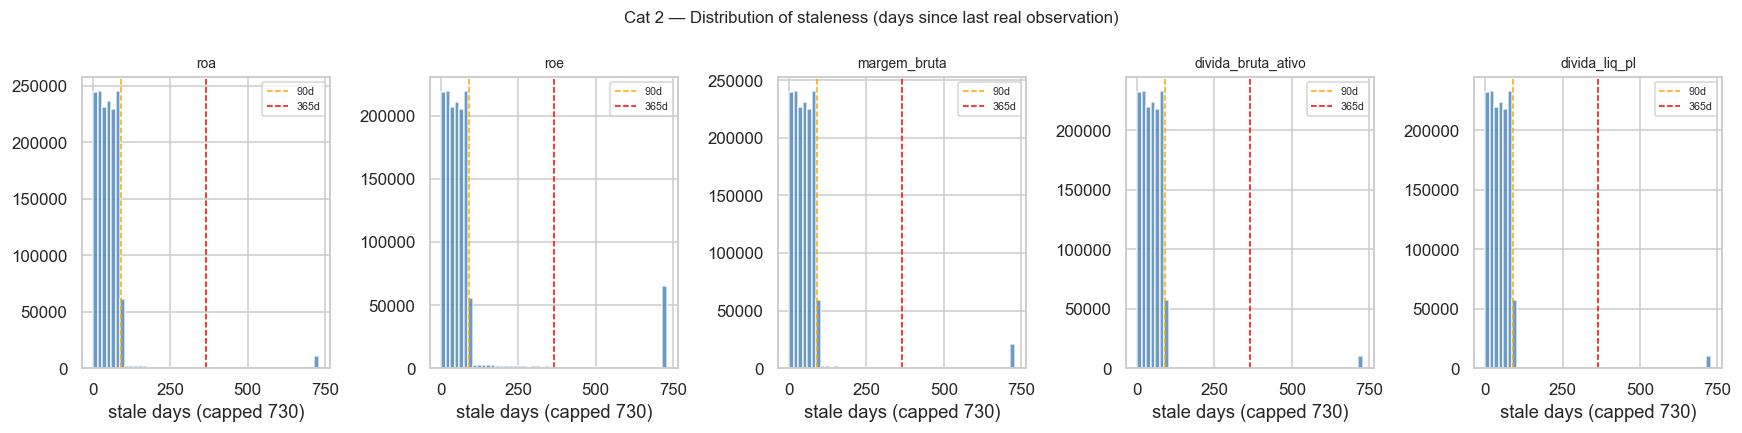


--- Tickers with >80% of observations stale >365d (for ROA) ---
Count: 1


TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

In [6]:
# ── Cat 2: Fundamental staleness ─────────────────────────────────────────────
# For each quarterly fundamental, compute stale_days = date - last_real_obs_date.
# Only quarterly features have meaningful staleness (daily features like pvpa/volume
# have observations every trading day and won't be stale in the same way).

QUARTERLY_COLS = ["roa", "roe", "margem_bruta", "divida_bruta_ativo", "divida_liq_pl"]

stale_results = {}
for col in QUARTERLY_COLS:
    clean = pd.read_parquet(CLEANED / f"{col}.parquet", columns=["date", "ticker"])
    clean = clean.rename(columns={"date": "obs_date"})
    # merge_asof requires right sorted by its key column globally (not per-ticker)
    clean = clean.sort_values("obs_date").reset_index(drop=True)

    # Non-null forward-filled observations
    ffill_col = fund_ffill[["date", "ticker", col]].dropna(subset=[col]).copy()
    # merge_asof requires left sorted by its key column globally (not per-ticker)
    ffill_col = ffill_col.sort_values("date").reset_index(drop=True)

    # For each (date, ticker) in ffill_col, find the most recent obs_date <= date
    merged = pd.merge_asof(
        ffill_col,
        clean,
        by="ticker",
        left_on="date",
        right_on="obs_date",
        direction="backward",
    )
    merged["stale_days"] = (merged["date"] - merged["obs_date"]).dt.days
    stale_results[col] = merged[["date", "ticker", "stale_days"]].dropna(subset=["stale_days"])

# Combine for summary table
summary_rows = []
for col, df in stale_results.items():
    df["year"] = df["date"].dt.year
    summary_rows.append(dict(
        feature        = col,
        median_stale   = round(df["stale_days"].median(), 0),
        p90_stale      = round(df["stale_days"].quantile(0.90), 0),
        pct_gt_90d     = round(100 * (df["stale_days"] > 90).mean(), 1),
        pct_gt_180d    = round(100 * (df["stale_days"] > 180).mean(), 1),
        pct_gt_365d    = round(100 * (df["stale_days"] > 365).mean(), 1),
        max_stale      = int(df["stale_days"].max()),
    ))

stale_summary = pd.DataFrame(summary_rows)
print("=== Fundamental Staleness Summary ===")
display(stale_summary)

# Plot: stale_days distribution per feature
fig, axes = plt.subplots(1, len(QUARTERLY_COLS), figsize=(16, 4), sharey=False)
for ax, col in zip(axes, QUARTERLY_COLS):
    d = stale_results[col]["stale_days"]
    ax.hist(d.clip(upper=730), bins=50, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(90,  color="orange", linestyle="--", linewidth=1, label="90d")
    ax.axvline(365, color="red",    linestyle="--", linewidth=1, label="365d")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("stale days (capped 730)")
    ax.legend(fontsize=7)
plt.suptitle("Cat 2 — Distribution of staleness (days since last real observation)", fontsize=11)
plt.tight_layout()
plt.show()

# Tickers with predominantly stale data
print("\n--- Tickers with >80% of observations stale >365d (for ROA) ---")
per_ticker = stale_results["roa"].groupby("ticker")["stale_days"].agg(
    pct_gt365=lambda x: (x > 365).mean()
)
bad_tickers = per_ticker[per_ticker["pct_gt365"] > 0.80]
print(f"Count: {len(bad_tickers)}")
if len(bad_tickers):
    display(bad_tickers.sort_values(ascending=False).head(20))

---
## Cat 3 — Outliers em Retornos

Os log-returns em `features/returns.parquet` **nunca são windsorisados**. Suspensões de negociação, 
reaberturas após circuit breaker, ou eventos corporativos (desdobramentos, agrupamentos) podem gerar 
retornos de >50% num único dia, distorcendo a normalização e o sinal do modelo.

**Diagnóstico**: distribuição dos retornos brutos, contagem de outliers por limiar e período,
e identificação dos casos mais extremos.

Return distribution — global: mean=0.00029, std=0.04999
  p0.1=-0.3430  p99.9=0.4055
  min=-3.9373  max=6.9722

--- Outlier counts by period (|return| > kσ) ---


,period,n_obs,>|3σ|,>|3σ|_%,>|5σ|,>|5σ|_%,>|10σ|,>|10σ|_%,>|20σ|,>|20σ|_%
0,test,295104,1843,0.625,484,0.164,116,0.039,19,0.006
1,train,1072952,19086,1.779,6851,0.639,1548,0.144,180,0.017
2,val,370516,3764,1.016,1148,0.310,249,0.067,35,0.009



--- Top 20 most extreme returns ---


,date,ticker,return,period
0,2007-07-13,CTMI3,6.972162,train
1,2019-03-27,GSHP3,4.941635,val
2,2005-04-20,EQMA3B,-3.937341,train
3,2009-09-25,MEND3,3.730035,train
4,2016-08-17,MRSA5B,-3.495215,train
5,2021-06-18,SHUL3,3.379513,val
6,2007-04-04,DHBI3,3.136112,train
7,2025-06-12,GOLL54,2.968896,test
8,2007-02-13,TROR4,2.677279,train
9,2016-06-02,PTPA3,2.532098,train


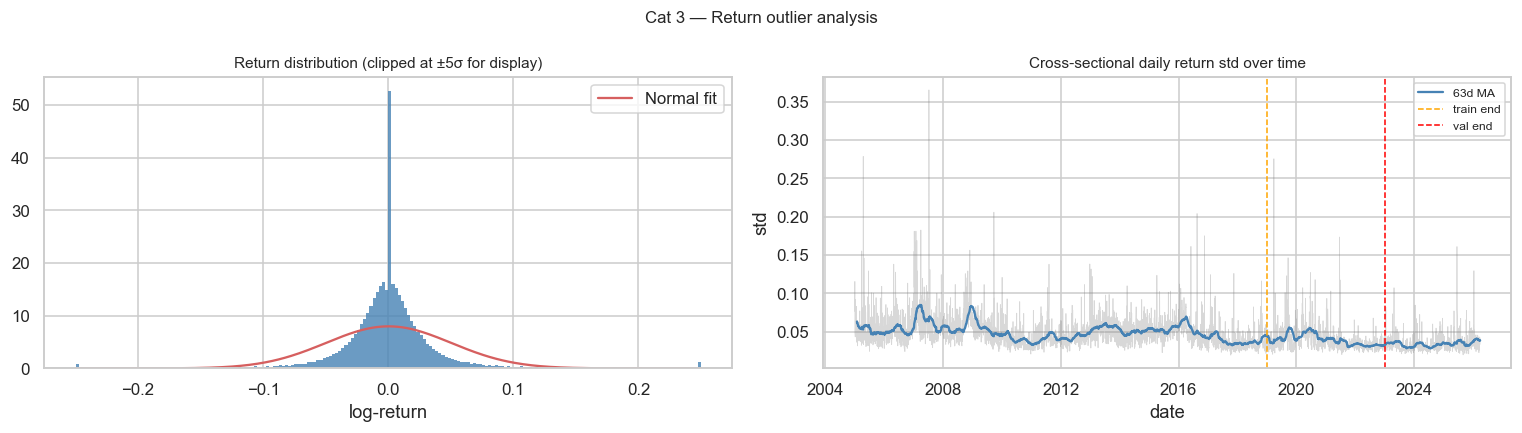

In [7]:
# ── Cat 3: Return outliers ───────────────────────────────────────────────────
ret = returns_raw.copy()
ret["period"] = ret["date"].apply(period_label)

global_std = ret["return"].std()
global_mean = ret["return"].mean()
print(f"Return distribution — global: mean={global_mean:.5f}, std={global_std:.5f}")
print(f"  p0.1={ret['return'].quantile(0.001):.4f}  p99.9={ret['return'].quantile(0.999):.4f}")
print(f"  min={ret['return'].min():.4f}  max={ret['return'].max():.4f}")

# Count outliers by threshold per period
print("\n--- Outlier counts by period (|return| > kσ) ---")
thresholds = [3, 5, 10, 20]
out_rows = []
for period, g in ret.groupby("period"):
    row = {"period": period, "n_obs": len(g)}
    for k in thresholds:
        mask = g["return"].abs() > k * global_std
        row[f">|{k}σ|"] = mask.sum()
        row[f">|{k}σ|_%"] = round(100 * mask.mean(), 3)
    out_rows.append(row)
display(pd.DataFrame(out_rows))

# Top-20 most extreme returns
print("\n--- Top 20 most extreme returns ---")
ret["abs_return"] = ret["return"].abs()
display(
    ret.nlargest(20, "abs_return")[["date", "ticker", "return", "period"]]
    .reset_index(drop=True)
)

# Rolling annual volatility
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: return histogram (winsorized for display only)
clip_val = 5 * global_std
axes[0].hist(ret["return"].clip(-clip_val, clip_val), bins=200, color="steelblue",
             alpha=0.8, edgecolor="none", density=True)
xx = np.linspace(-clip_val, clip_val, 300)
axes[0].plot(xx, stats.norm.pdf(xx, global_mean, global_std), "r-", linewidth=1.5, label="Normal fit")
axes[0].set_title("Return distribution (clipped at ±5σ for display)", fontsize=10)
axes[0].set_xlabel("log-return"); axes[0].legend()

# Right: cross-sectional daily std (volatility proxy) over time
daily_std = ret.groupby("date")["return"].std().reset_index()
daily_std.columns = ["date", "xsec_std"]
daily_std["rolling"] = daily_std["xsec_std"].rolling(63, min_periods=20).mean()
axes[1].plot(daily_std["date"], daily_std["xsec_std"], alpha=0.3, color="grey", linewidth=0.5)
axes[1].plot(daily_std["date"], daily_std["rolling"], color="steelblue", linewidth=1.5, label="63d MA")
for ts, label, color in [(TRAIN_END_TS,"train end","orange"), (VAL_END_TS,"val end","red")]:
    axes[1].axvline(ts, color=color, linestyle="--", linewidth=1, label=label)
axes[1].set_title("Cross-sectional daily return std over time", fontsize=10)
axes[1].set_xlabel("date"); axes[1].set_ylabel("std"); axes[1].legend(fontsize=8)

plt.suptitle("Cat 3 — Return outlier analysis", fontsize=11)
plt.tight_layout()
plt.show()

---
## Cat 4 — Survivorship Bias

Se a Economatica fornece dados apenas de empresas que **ainda existem** (ou que sobreviveram até a data de download), 
o modelo treina apenas em casos de sucesso e nunca aprende o padrão de deterioração que precede falências e delistings.

**Diagnóstico**: verificar o padrão de entrada/saída de tickers no dataset — quantas empresas "desaparecem" 
antes do fim do período, e qual seu nível de preço na última observação.

Dataset date range: 2005-01-03 → 2026-03-26
  Total tickers        : 975
  Active (last obs >= 2025-03-26): 443
  Exiting (likely delisted): 532
  Exit rate: 54.6%

  Median last price of exiting tickers: R$ 9.93


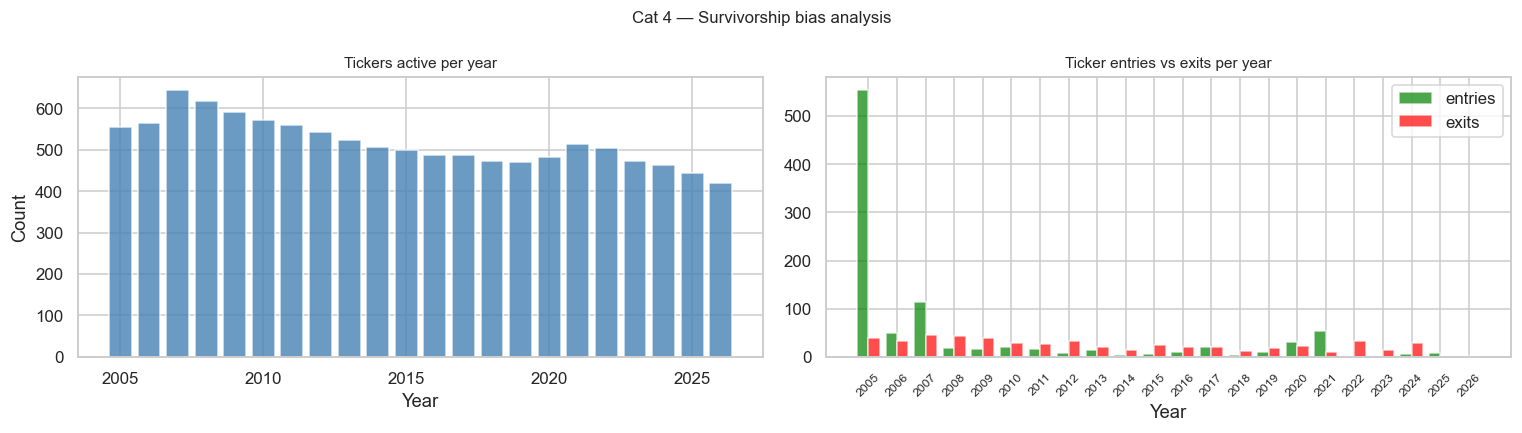

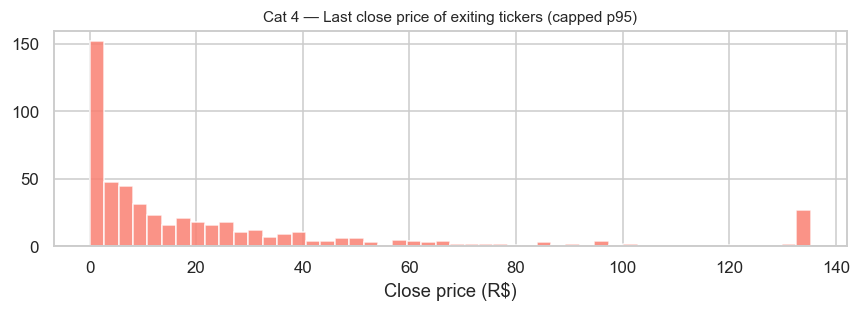

In [9]:

# ── Cat 4: Survivorship bias ─────────────────────────────────────────────────
p = prices[["date", "ticker", "close"]].copy()
p["year"] = p["date"].dt.year

# First and last observation date per ticker
ticker_bounds = p.groupby("ticker")["date"].agg(first_obs="min", last_obs="max").reset_index()

# Add year columns before slicing
ticker_bounds["entry_year"] = ticker_bounds["first_obs"].dt.year
ticker_bounds["exit_year"]  = ticker_bounds["last_obs"].dt.year

dataset_end = p["date"].max()
RECENT_CUTOFF = dataset_end - pd.DateOffset(years=1)

# Exiting tickers: last_obs < dataset_end - 1 year (likely delisted/merged)
exiting = ticker_bounds[ticker_bounds["last_obs"] < RECENT_CUTOFF].copy()
active  = ticker_bounds[ticker_bounds["last_obs"] >= RECENT_CUTOFF].copy()

print(f"Dataset date range: {p['date'].min().date()} → {dataset_end.date()}")
print(f"  Total tickers        : {len(ticker_bounds)}")
print(f"  Active (last obs >= {RECENT_CUTOFF.date()}): {len(active)}")
print(f"  Exiting (likely delisted): {len(exiting)}")
print(f"  Exit rate: {100*len(exiting)/len(ticker_bounds):.1f}%")

# Price at last observation for exiting tickers
last_prices = p.sort_values("date").groupby("ticker").last()["close"].rename("last_close")
exiting = exiting.merge(last_prices, on="ticker", how="left")
print(f"\n  Median last price of exiting tickers: R$ {exiting['last_close'].median():.2f}")

years = sorted(p["year"].unique())
entry_by_year = ticker_bounds["entry_year"].value_counts().sort_index()
exit_by_year  = exiting["exit_year"].value_counts().sort_index()

# Active tickers per year
active_per_year = {}
for yr in years:
    yr_start = pd.Timestamp(f"{yr}-01-01")
    yr_end   = pd.Timestamp(f"{yr}-12-31")
    active_per_year[yr] = ((ticker_bounds["first_obs"] <= yr_end) &
                           (ticker_bounds["last_obs"]  >= yr_start)).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: tickers active per year
axes[0].bar(list(active_per_year.keys()), list(active_per_year.values()), color="steelblue", alpha=0.8)
axes[0].set_title("Tickers active per year", fontsize=10)
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Count")

# Right: entries vs exits per year
ax2 = axes[1]
bar_w = 0.4
entry_y = [entry_by_year.get(yr, 0) for yr in years]
exit_y  = [exit_by_year.get(yr, 0)  for yr in years]
x = range(len(years))
ax2.bar([i - bar_w/2 for i in x], entry_y, width=bar_w, label="entries", color="green", alpha=0.7)
ax2.bar([i + bar_w/2 for i in x], exit_y,  width=bar_w, label="exits",   color="red",   alpha=0.7)
ax2.set_xticks(list(x)); ax2.set_xticklabels(years, rotation=45, fontsize=8)
ax2.set_title("Ticker entries vs exits per year", fontsize=10)
ax2.set_xlabel("Year"); ax2.legend()

plt.suptitle("Cat 4 — Survivorship bias analysis", fontsize=11)
plt.tight_layout(); plt.show()

# Last-price distribution for exiting tickers
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(exiting["last_close"].clip(upper=exiting["last_close"].quantile(0.95)),
        bins=50, color="salmon", edgecolor="white", alpha=0.85)
ax.set_title("Cat 4 — Last close price of exiting tickers (capped p95)", fontsize=10)
ax.set_xlabel("Close price (R$)")
plt.tight_layout(); plt.show()


---
## Cat 5 — Distribution Shift (Train → Val → Test)

As features são normalizadas com estatísticas do período de treino (2005–2018). Se as distribuições mudarem 
nos períodos seguintes, as features chegam ao modelo em escala diferente da treinada — uma forma implícita de degradação.

**Diagnóstico**: estatísticas descritivas e KS-test por período para cada uma das 41 features.

=== Distribution Shift: KS-test (train vs test) — top 20 most shifted ===


,feature,train_mean,val_mean,test_mean,train_std,val_std,test_std,ks_stat,ks_pval,significant
11,fcf_yield,0.0,0.027,0.031,0.773,0.714,1.089,0.2231,0.0,True
15,BZDIOVRA Index_ret,0.0,0.160,0.042,1.000,3.122,0.792,0.2006,0.0,True
8,preco_lucro,-0.0,0.036,-0.084,0.958,1.089,0.765,0.1880,0.0,True
6,pvpa,0.0,0.002,-0.204,0.965,0.970,0.735,0.1794,0.0,True
7,ev_ebitda,0.0,0.082,-0.035,0.910,0.844,0.627,0.1728,0.0,True
10,fcf_divida,-0.0,0.000,0.028,0.759,0.951,0.991,0.1626,0.0,True
9,volume,-0.0,0.599,0.516,1.000,1.962,1.860,0.1411,0.0,True
1,roa,0.0,0.037,0.054,0.912,0.837,0.813,0.1302,0.0,True
19,MXBR000V Index_ret,0.0,-0.013,0.010,1.000,1.043,0.562,0.1228,0.0,True
2,roe,0.0,-0.127,-0.111,0.887,1.252,1.122,0.1213,0.0,True



Features with significant shift (p<0.01): 41 / 41


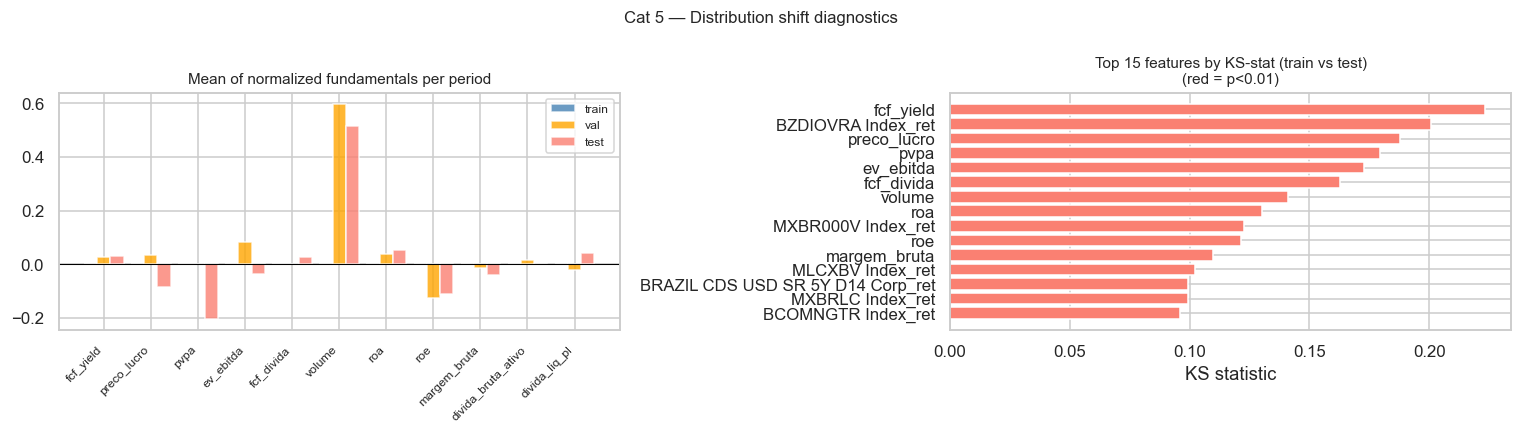

In [10]:
# ── Cat 5: Distribution shift ────────────────────────────────────────────────
train_x = x_ts[x_ts["period"] == "train"]
val_x   = x_ts[x_ts["period"] == "val"]
test_x  = x_ts[x_ts["period"] == "test"]

shift_rows = []
for col in FEATURE_COLS:
    tr = train_x[col].dropna()
    vl = val_x[col].dropna()
    te = test_x[col].dropna()
    if len(te) == 0:
        continue

    ks_tv, pv_tv = stats.ks_2samp(tr, te) if len(tr) > 0 and len(te) > 0 else (np.nan, np.nan)

    shift_rows.append(dict(
        feature      = col,
        train_mean   = round(tr.mean(), 3),
        val_mean     = round(vl.mean(), 3) if len(vl) > 0 else np.nan,
        test_mean    = round(te.mean(), 3),
        train_std    = round(tr.std(), 3),
        val_std      = round(vl.std(),  3) if len(vl) > 0 else np.nan,
        test_std     = round(te.std(), 3),
        ks_stat      = round(ks_tv, 4),
        ks_pval      = round(pv_tv, 4),
        significant  = pv_tv < 0.01,
    ))

shift_df = pd.DataFrame(shift_rows).sort_values("ks_stat", ascending=False)
print("=== Distribution Shift: KS-test (train vs test) — top 20 most shifted ===")
display(shift_df.head(20))
print(f"\nFeatures with significant shift (p<0.01): {shift_df['significant'].sum()} / {len(shift_df)}")

# Plot: mean drift across periods for fundamentals + composites
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat_subset = FUND_COLS + COMPOSITE_COLS
means = shift_df[shift_df["feature"].isin(feat_subset)][["feature","train_mean","val_mean","test_mean"]]
means = means.set_index("feature")

ax = axes[0]
x_pos = np.arange(len(means))
width = 0.28
ax.bar(x_pos - width, means["train_mean"], width, label="train", color="steelblue", alpha=0.8)
ax.bar(x_pos,         means["val_mean"],   width, label="val",   color="orange",    alpha=0.8)
ax.bar(x_pos + width, means["test_mean"],  width, label="test",  color="salmon",    alpha=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(means.index, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Mean of normalized fundamentals per period", fontsize=10)
ax.legend(fontsize=8)

# Right: KS stats bar chart (top 15)
top15 = shift_df.head(15)
axes[1].barh(top15["feature"][::-1], top15["ks_stat"][::-1],
             color=["salmon" if s else "steelblue" for s in top15["significant"][::-1]])
axes[1].set_title("Top 15 features by KS-stat (train vs test)\n(red = p<0.01)", fontsize=10)
axes[1].set_xlabel("KS statistic")

plt.suptitle("Cat 5 — Distribution shift diagnostics", fontsize=11)
plt.tight_layout(); plt.show()

---
## Cat 6 — Contaminação por Zero-Fill

Em `08_assemble_x_ts.py`, NaN residuais são preenchidos com `0.0`. Após a normalização z-score, 0.0 equivale 
à **média do treino** — tornando ausência de dado e "empresa exatamente mediana" indistinguíveis.

**Diagnóstico**: comparar a taxa de NaN em `features/fundamentals_ffill.parquet` (pré-normalização) 
com a taxa de zeros em `parquets/x_ts.parquet` para confirmar a origem dos zeros, e entender como isso evolui por ano.

=== Zero-Fill Contamination ===


,feature,nan_rate_pct,zero_rate_in_xts_pct,zeros_from_nan,pct_zeros_from_nan
0,roa,11.90,11.85,206012.0,100.0
1,roe,16.26,16.21,281902.0,100.0
2,margem_bruta,12.94,12.89,224188.0,100.0
3,divida_bruta_ativo,16.93,16.89,293599.0,100.0
4,divida_liq_pl,16.93,16.89,293599.0,100.0
5,pvpa,4.58,4.58,79634.0,100.0
6,ev_ebitda,15.16,15.15,263310.0,100.0
7,preco_lucro,5.76,5.75,99957.0,100.0
8,volume,0.00,0.00,0.0,0.0
9,fcf_divida,NaN,32.51,NaN,NaN



--- Zero rate per year (quarterly fundamentals) ---


,roa,roe,margem_bruta,divida_bruta_ativo,divida_liq_pl
year,,,,,
2005,0.485,0.517,0.491,0.489,0.489
2006,0.300,0.339,0.308,0.310,0.310
2007,0.344,0.396,0.357,0.315,0.315
2008,0.253,0.310,0.263,0.256,0.256
2009,0.172,0.232,0.185,0.228,0.228
2010,0.171,0.213,0.183,0.212,0.212
2011,0.150,0.190,0.160,0.179,0.179
2012,0.105,0.151,0.112,0.159,0.159
2013,0.098,0.144,0.105,0.162,0.162


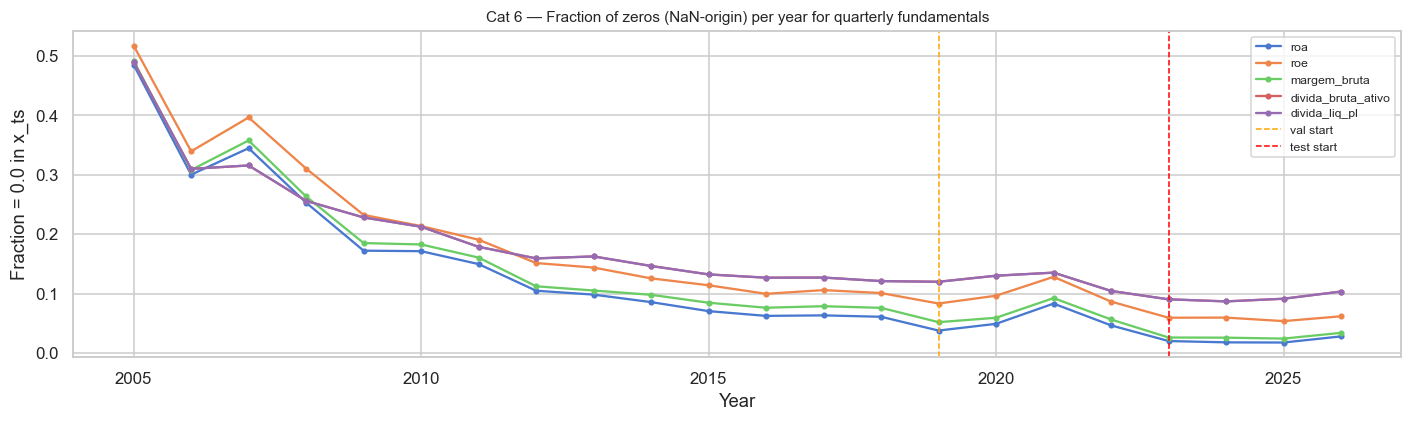


Tickers with >80% zeros across all fundamentals: 18


ticker
BAHI4     0.888889
GTDP4B    0.888889
DUFB11    0.888889
GTDP3B    0.888889
SCLO3     0.888889
LREN4     0.888889
DOMO3     0.888889
SCLO4     0.884718
CESP5     0.848995
ADMF3     0.846296
ODER4     0.839506
CBMA4     0.826910
CBMA3     0.824193
CCTY3     0.823529
CRIV4     0.822904
CSUD3     0.814687
CESP3     0.810405
CESP6     0.807681
dtype: float64

In [11]:
# ── Cat 6: Zero-fill contamination ───────────────────────────────────────────
# Step A: NaN rate in fund_ffill vs zero rate in x_ts per feature
nan_rows = []
for col in FUND_COLS + COMPOSITE_COLS:
    nan_rate_ffill = fund_ffill[col].isna().mean() if col in fund_ffill.columns else np.nan
    # In x_ts the value is normalized; a zero could be a filled NaN *or* a genuine mean
    # We identify NaN-origin zeros: if fund_ffill was NaN, x_ts is 0 after fill
    if col in fund_ffill.columns and col in x_ts.columns:
        # Merge to align
        tmp = x_ts[["date","ticker", col]].merge(
            fund_ffill[["date","ticker", col]].rename(columns={col: f"{col}_raw"}),
            on=["date","ticker"], how="left"
        )
        zero_from_nan = ((tmp[f"{col}_raw"].isna()) & (tmp[col] == 0.0)).sum()
        total_zeros   = (tmp[col] == 0.0).sum()
        pct_zeros_from_nan = 100 * zero_from_nan / total_zeros if total_zeros > 0 else 0
    else:
        zero_from_nan = np.nan
        total_zeros   = np.nan
        pct_zeros_from_nan = np.nan

    nan_rows.append(dict(
        feature             = col,
        nan_rate_pct        = round(100 * nan_rate_ffill, 2),
        zero_rate_in_xts_pct= round(100 * (x_ts[col] == 0.0).mean(), 2) if col in x_ts.columns else np.nan,
        zeros_from_nan      = int(zero_from_nan) if not np.isnan(zero_from_nan) else np.nan,
        pct_zeros_from_nan  = round(pct_zeros_from_nan, 1),
    ))

zerofill_df = pd.DataFrame(nan_rows)
print("=== Zero-Fill Contamination ===")
display(zerofill_df)

# Step B: Zero rate per year for quarterly fundamentals in x_ts
x_ts["year"] = x_ts["date"].dt.year
yearly_zero = {}
for col in FUND_COLS[:5]:  # quarterly only
    if col not in x_ts.columns:
        continue
    yr_rate = x_ts.groupby("year")[col].apply(lambda s: (s == 0.0).mean())
    yearly_zero[col] = yr_rate

yz_df = pd.DataFrame(yearly_zero)
print("\n--- Zero rate per year (quarterly fundamentals) ---")
display(yz_df.round(3))

fig, ax = plt.subplots(figsize=(13, 4))
for col in yz_df.columns:
    ax.plot(yz_df.index, yz_df[col], marker="o", markersize=3, label=col)
ax.axvline(2019, color="orange", linestyle="--", linewidth=1, label="val start")
ax.axvline(2023, color="red",    linestyle="--", linewidth=1, label="test start")
ax.set_title("Cat 6 — Fraction of zeros (NaN-origin) per year for quarterly fundamentals", fontsize=10)
ax.set_xlabel("Year"); ax.set_ylabel("Fraction = 0.0 in x_ts")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# Step C: Tickers with >80% zeros across all fundamentals
fund_x = x_ts[FUND_COLS].copy()
per_ticker_zeros = x_ts.groupby("ticker")[FUND_COLS].apply(
    lambda g: (g == 0.0).mean().mean()
)
bad = per_ticker_zeros[per_ticker_zeros > 0.8]
print(f"\nTickers with >80% zeros across all fundamentals: {len(bad)}")
if len(bad):
    display(bad.sort_values(ascending=False).head(20))

---
## Cat 7 — Patologias das Features Compostas (FCF/Dívida e FCF Yield)

As features compostas dependem de dois numeradores/denominadores trimestrais cada um, resultando numa perda de 
cobertura composta: se FCF **e** Dívida têm ~60% de cobertura, FCF/Dívida terá no máximo ~36%.
Além disso, a winsorização foi aplicada no dataset completo, replicando o look-ahead bias da Cat 1.

**Diagnóstico**: cobertura pre/post ffill, distribuição dos ratios, e comparação train vs full-sample bounds.

FCF/Dívida:
  Total rows  : 1,739,547
  Non-null    : 1,173,313  (67.4%)
  NaN (=0 in x_ts): 566,234  (32.6%)
  Range post-ffill: [-10.2345, 10.5376]
  mean=0.2083  std=2.1681  median=0.0507
  Train p1=-10.2345  p99=10.5376
  Full  p1=-10.2345  p99=10.5376

FCF Yield:
  Total rows  : 1,739,547
  Non-null    : 1,215,366  (69.9%)
  NaN (=0 in x_ts): 524,181  (30.1%)
  Range post-ffill: [-2.1163, 2.5108]
  mean=0.0215  std=0.4788  median=0.0281
  Train p1=-2.0734  p99=2.5108
  Full  p1=-2.1163  p99=2.5106



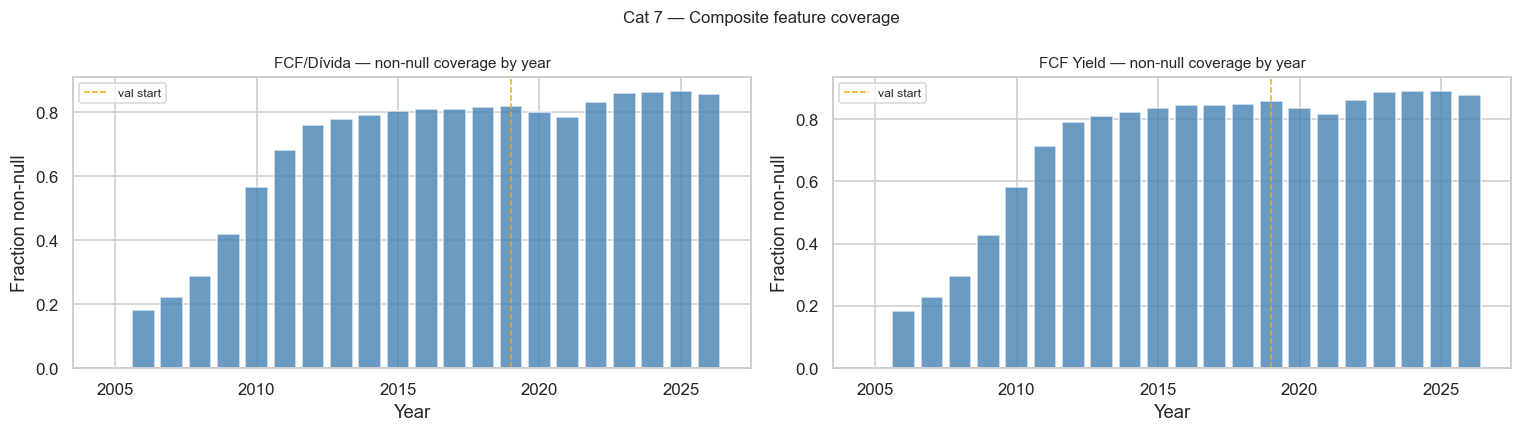

--- Raw input coverage ---
  FCF: 41,120 rows, 993 tickers, 100.0% non-null
  Dívida Total: 54,081 rows, 1124 tickers, 100.0% non-null
  Market Cap: 3,245,677 rows, 1079 tickers, 100.0% non-null


In [12]:
# ── Cat 7: Composite feature pathologies ─────────────────────────────────────
for label, df, col in [
    ("FCF/Dívida", fcf_div,      "fcf_divida"),
    ("FCF Yield",  fcf_yield_df, "fcf_yield"),
]:
    total  = len(df)
    n_null = df[col].isna().sum()
    n_valid= total - n_null
    print(f"{label}:")
    print(f"  Total rows  : {total:,}")
    print(f"  Non-null    : {n_valid:,}  ({100*n_valid/total:.1f}%)")
    print(f"  NaN (=0 in x_ts): {n_null:,}  ({100*n_null/total:.1f}%)")

    if n_valid > 0:
        s = df[col].dropna()
        print(f"  Range post-ffill: [{s.min():.4f}, {s.max():.4f}]")
        print(f"  mean={s.mean():.4f}  std={s.std():.4f}  median={s.median():.4f}")

        # Train-only bounds vs full-sample bounds
        train_df = df[df["date"] <= TRAIN_END_TS]
        if len(train_df) > 0:
            s_tr = train_df[col].dropna()
            print(f"  Train p1={s_tr.quantile(0.01):.4f}  p99={s_tr.quantile(0.99):.4f}")
            print(f"  Full  p1={s.quantile(0.01):.4f}  p99={s.quantile(0.99):.4f}")
    print()

# Coverage over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, df, col) in zip(axes, [
    ("FCF/Dívida", fcf_div,      "fcf_divida"),
    ("FCF Yield",  fcf_yield_df, "fcf_yield"),
]):
    df2 = df.copy()
    df2["year"] = df2["date"].dt.year
    cov = df2.groupby("year")[col].apply(lambda s: s.notna().mean())
    ax.bar(cov.index, cov.values, color="steelblue", alpha=0.8, edgecolor="white")
    ax.axvline(2019, color="orange", linestyle="--", linewidth=1, label="val start")
    ax.set_title(f"{label} — non-null coverage by year", fontsize=10)
    ax.set_ylabel("Fraction non-null"); ax.set_xlabel("Year")
    ax.legend(fontsize=8)

plt.suptitle("Cat 7 — Composite feature coverage", fontsize=11)
plt.tight_layout(); plt.show()

# Raw input coverage check
print("--- Raw input coverage ---")
for raw_path, label in [(FCF_PATH, "FCF"), (DIVIDA_TOTAL_PATH, "Dívida Total"), (MKTCAP_PATH, "Market Cap")]:
    raw = read_economatica_wide(raw_path, label.lower().replace(" ", "_"))
    print(f"  {label}: {raw.shape[0]:,} rows, "
          f"{raw['ticker'].nunique()} tickers, "
          f"{100*raw.iloc[:,2].notna().mean():.1f}% non-null")

---
## Cat 8 — Dupla Exposição ON/PN

No mercado brasileiro, uma mesma empresa pode ter múltiplas classes de ações: XXXX3 (ON), XXXX4 (PN), XXXX11 (Units).
Se ambas estiverem no dataset, os fundamentos são computados para a **mesma empresa**, criando exemplos de treino quase idênticos com retornos altamente correlacionados.

**Diagnóstico**: identificar pares/grupos de ações da mesma empresa, medir a correlação de retornos e quantificar o grau de duplicação.

=== ON/PN Duplicate Exposure ===
Total tickers: 956
Unique company bases: 622
Companies with >1 ticker class: 262
Extra tickers due to duplication: 334

--- Top 20 companies with most classes ---


,base,ticker,n_classes
108,BRGE,"[BRGE11, BRGE12, BRGE3, BRGE5, BRGE6, BRGE7, B...",7
561,TMAC,"[TMAC11B, TMAC3B, TMAC5B, TMAC6B, TMAC7B, TMAC8B]",6
564,TMGC,"[TMGC11, TMGC12, TMGC13, TMGC3, TMGC6, TMGC7]",6
114,BRSR,"[BRSR11, BRSR3, BRSR5, BRSR6]",4
312,IGBR,"[IGBR3, IGBR5, IGBR6, IGBR7]",4
250,EQPA,"[EQPA3, EQPA5, EQPA6, EQPA7]",4
57,AXIA,"[AXIA3, AXIA5, AXIA6, AXIA7]",4
166,CPLE,"[CPLE11, CPLE3, CPLE5, CPLE6]",4
570,TPEC,"[TPEC3B, TPEC6B, TPEC7B, TPEC8B]",4
533,SULA,"[SULA11, SULA3, SULA4]",3



--- Return correlation between paired classes (train period) ---


,base,t1,t2,corr,n
239,VALE,VALE3,VALE5,0.9664,3190
194,PETR,PETR3,PETR4,0.9628,3458
242,BBDC,BBDC3,BBDC4,0.8965,3458
20,AXIA,AXIA3,AXIA6,0.8927,3458
158,GGBR,GGBR3,GGBR4,0.8843,3458
173,LFFE,LFFE3,LFFE4,0.8760,64
149,CMIG,CMIG3,CMIG4,0.8342,3458
159,GOAU,GOAU3,GOAU4,0.8180,3431
153,FCAP,FCAP3,FCAP4,0.7877,197
170,ITUB,ITUB3,ITUB4,0.7806,3366



Median pairwise correlation: 0.3451


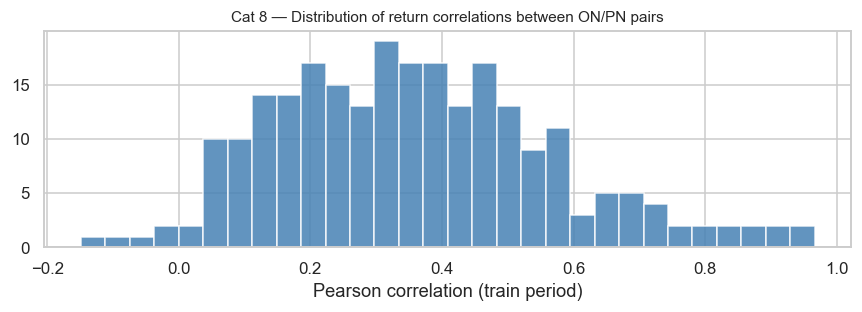

In [13]:
# ── Cat 8: ON/PN duplicate exposure ─────────────────────────────────────────
import re

all_tickers = sorted(x_ts["ticker"].unique())

# Extract base name (strip trailing digits and suffix like 3,4,5,6,11,34)
def ticker_base(t: str) -> str:
    m = re.match(r"^([A-Z]+)", t)
    return m.group(1) if m else t

def ticker_suffix(t: str) -> str:
    m = re.search(r"(\d+)$", t)
    return m.group(1) if m else ""

t_df = pd.DataFrame({"ticker": all_tickers})
t_df["base"]   = t_df["ticker"].apply(ticker_base)
t_df["suffix"] = t_df["ticker"].apply(ticker_suffix)

# Groups with more than one ticker sharing the same base
groups = t_df.groupby("base")["ticker"].apply(list).reset_index()
groups = groups[groups["ticker"].apply(len) > 1].copy()
groups["n_classes"] = groups["ticker"].apply(len)
groups = groups.sort_values("n_classes", ascending=False)

print(f"=== ON/PN Duplicate Exposure ===")
print(f"Total tickers: {len(all_tickers)}")
print(f"Unique company bases: {len(t_df['base'].unique())}")
print(f"Companies with >1 ticker class: {len(groups)}")
print(f"Extra tickers due to duplication: {groups['n_classes'].sum() - len(groups)}")
print()
print(f"--- Top 20 companies with most classes ---")
display(groups.head(20))

# Correlation between paired tickers (ON vs PN)
# Use the train period to compute correlations
ret_wide = returns_raw[returns_raw["date"] <= TRAIN_END_TS].pivot_table(
    index="date", columns="ticker", values="return"
)

corr_rows = []
for _, row in groups.iterrows():
    tks = row["ticker"]
    for i in range(len(tks)):
        for j in range(i + 1, len(tks)):
            t1, t2 = tks[i], tks[j]
            if t1 in ret_wide.columns and t2 in ret_wide.columns:
                paired = ret_wide[[t1, t2]].dropna()
                if len(paired) > 50:
                    r = paired.corr().iloc[0, 1]
                    corr_rows.append({"base": row["base"], "t1": t1, "t2": t2, "corr": round(r, 4), "n": len(paired)})

if corr_rows:
    corr_df = pd.DataFrame(corr_rows).sort_values("corr", ascending=False)
    print(f"\n--- Return correlation between paired classes (train period) ---")
    display(corr_df.head(30))
    print(f"\nMedian pairwise correlation: {corr_df['corr'].median():.4f}")
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(corr_df["corr"], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title("Cat 8 — Distribution of return correlations between ON/PN pairs", fontsize=10)
    ax.set_xlabel("Pearson correlation (train period)")
    plt.tight_layout(); plt.show()
else:
    print("Not enough overlap to compute pairwise correlations.")

---
## Cat 9 — Correlação entre Features / Redundância

Com 29 features de índice global mais 12 features ticker-específicas, existe o risco de alta colinearidade 
(especialmente entre índices de equity correlacionados) e redundância aritmética (ex: pvpa ≈ roe × preco_lucro).

**Diagnóstico**: matriz de correlação 41×41 + PCA dos índices para medir redutibilidade dimensional.

=== High-correlation pairs (|r| >= 0.75) ===
Total: 26


,feat_1,feat_2,corr
15,IDIV Index_ret,MU702608 Index_ret,0.9997
8,MXBRLC Index_ret,MU702608 Index_ret,0.9790
6,MXBRLC Index_ret,IDIV Index_ret,0.9788
20,BZRFIMAB Index_ret,BZRFIMA Index_ret,0.9753
9,MXBRLC Index_ret,MXLA Index_ret,0.9747
19,MU702608 Index_ret,MXLA Index_ret,0.9669
16,IDIV Index_ret,MXLA Index_ret,0.9666
11,MXBR000V Index_ret,MLCXBV Index_ret,0.9511
25,MXGB Index_ret,MXEU Index_ret,0.9369
3,MXBRSC Index_ret,MU702608 Index_ret,0.9201


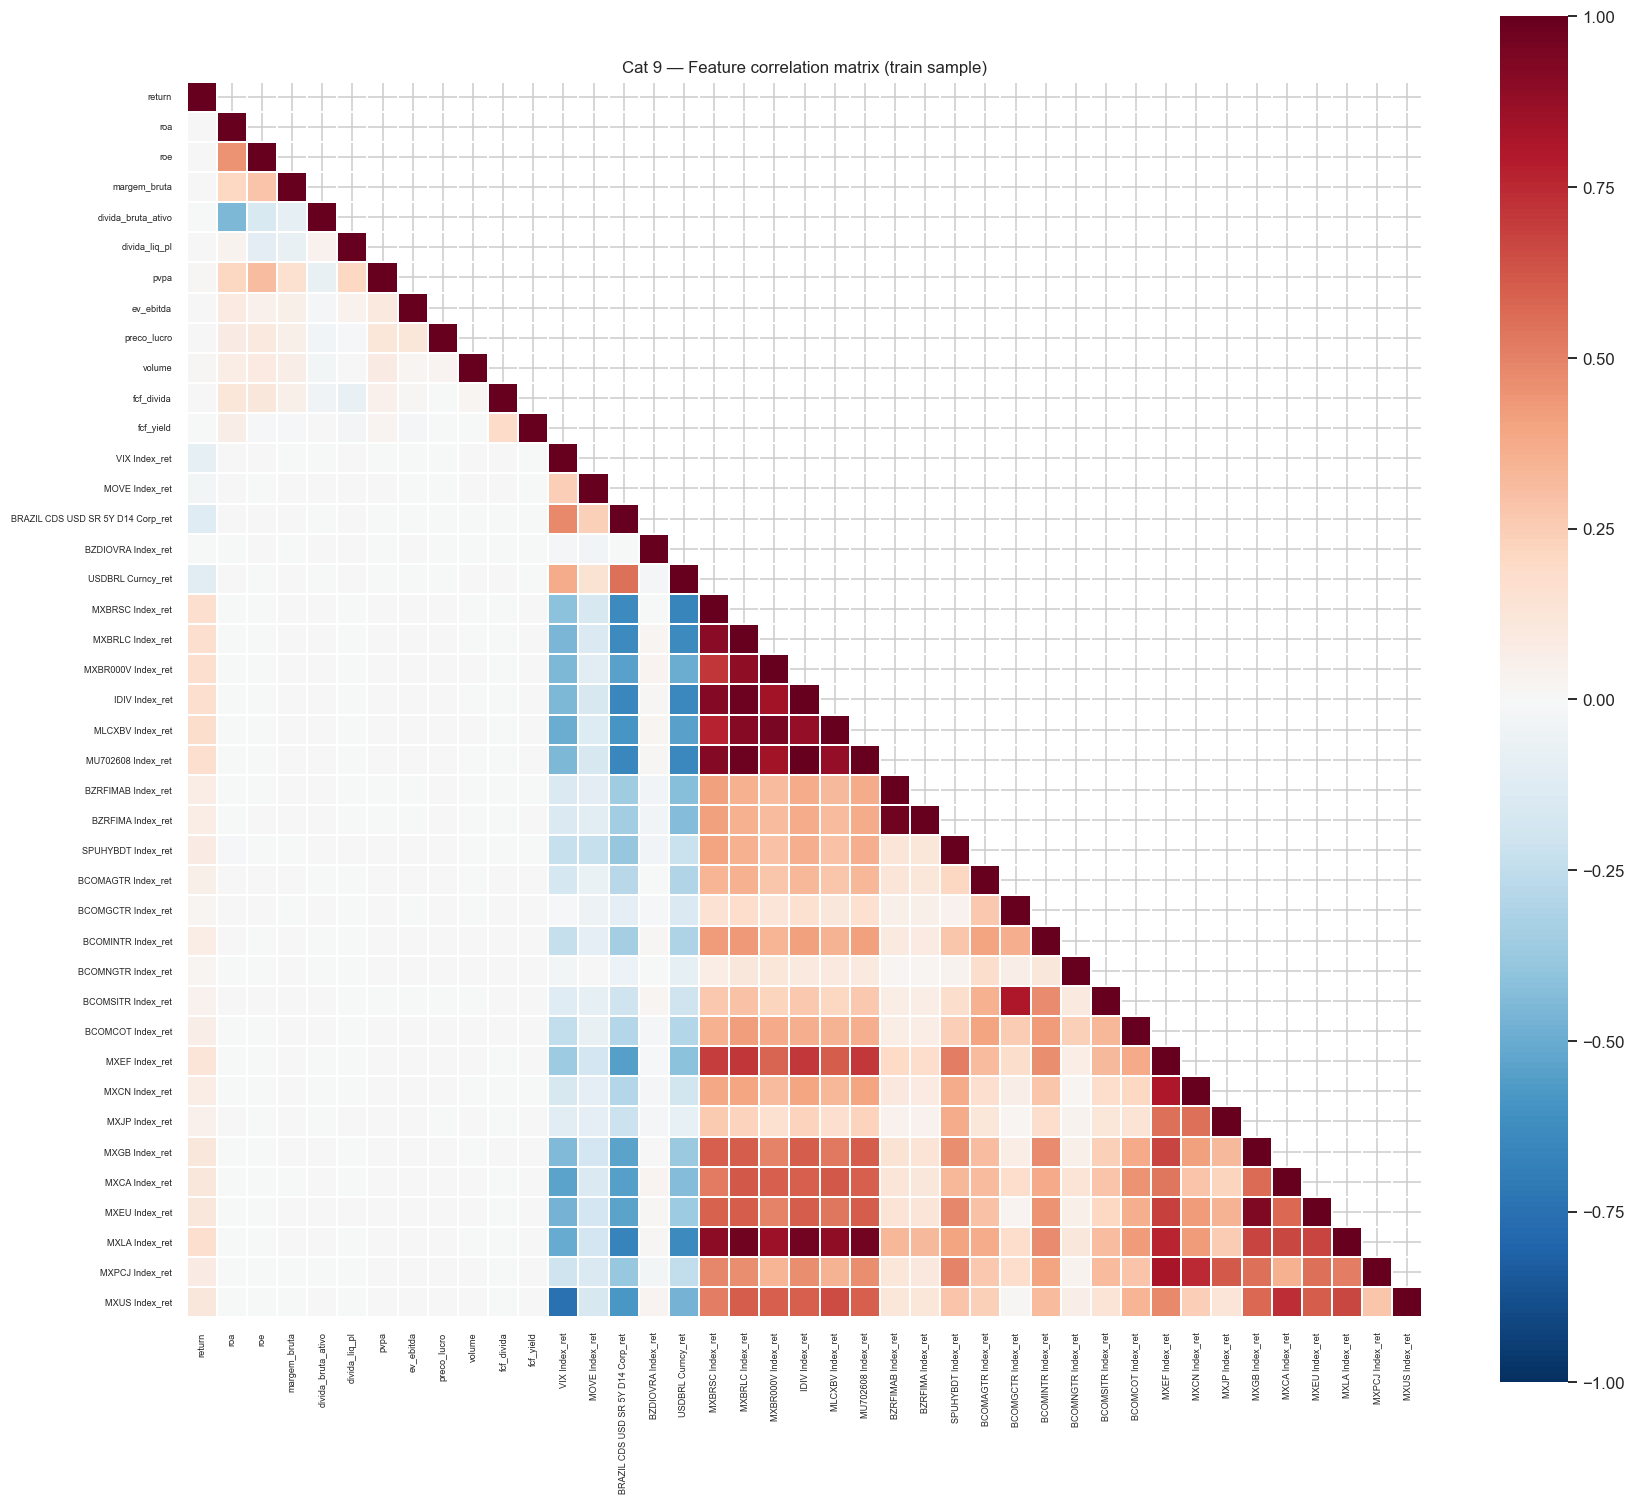


=== PCA on 29 index features ===
  Components to explain 90% variance: 13
  Components to explain 95% variance: 17
  Variance of PC1: 0.419


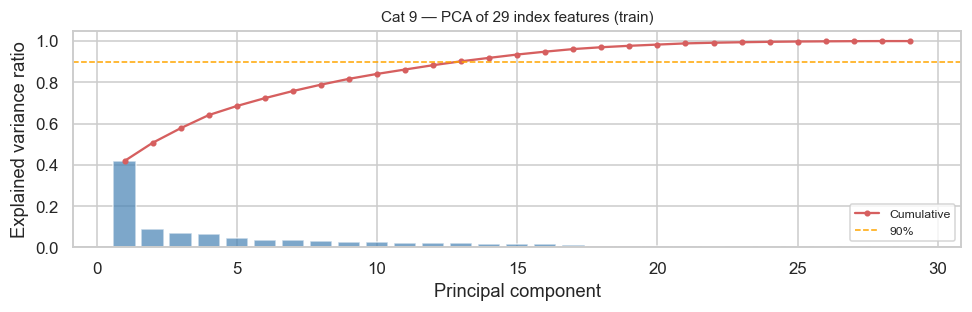

In [14]:
# ── Cat 9: Feature correlation + PCA ─────────────────────────────────────────
# Use a sample from train period to compute correlations
train_sample = train_x[FEATURE_COLS].dropna(how="all")
# Subsample for speed if large
if len(train_sample) > 300_000:
    train_sample = train_sample.sample(300_000, random_state=42)

corr_matrix = train_sample.corr()

# High-correlation pairs
high_corr_rows = []
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.75:
            high_corr_rows.append({"feat_1": cols[i], "feat_2": cols[j], "corr": round(r, 4)})

high_corr_df = pd.DataFrame(high_corr_rows).sort_values("corr", key=abs, ascending=False)
print(f"=== High-correlation pairs (|r| >= 0.75) ===")
print(f"Total: {len(high_corr_df)}")
display(high_corr_df.head(30))

# Full correlation heatmap
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # keep lower triangle
sns.heatmap(
    corr_matrix, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True, annot=False, ax=ax,
    xticklabels=True, yticklabels=True
)
ax.tick_params(axis="both", labelsize=6)
ax.set_title("Cat 9 — Feature correlation matrix (train sample)", fontsize=11)
plt.tight_layout(); plt.show()

# PCA on index features only
idx_data = train_sample[IDX_COLS].dropna()
if len(idx_data) > 100:
    pca = PCA().fit(idx_data.values)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    n90 = np.searchsorted(cum_var, 0.90) + 1
    n95 = np.searchsorted(cum_var, 0.95) + 1

    print(f"\n=== PCA on {len(IDX_COLS)} index features ===")
    print(f"  Components to explain 90% variance: {n90}")
    print(f"  Components to explain 95% variance: {n95}")
    print(f"  Variance of PC1: {pca.explained_variance_ratio_[0]:.3f}")

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(range(1, len(pca.explained_variance_ratio_) + 1),
           pca.explained_variance_ratio_, color="steelblue", alpha=0.7)
    ax.plot(range(1, len(cum_var) + 1), cum_var, "r-o", markersize=3, label="Cumulative")
    ax.axhline(0.90, color="orange", linestyle="--", linewidth=1, label="90%")
    ax.set_title(f"Cat 9 — PCA of {len(IDX_COLS)} index features (train)", fontsize=10)
    ax.set_xlabel("Principal component"); ax.set_ylabel("Explained variance ratio")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

---
## Cat 10 — Variância Cross-Sectional vs Temporal

As 29 features de índice têm o mesmo valor para **todos os tickers** no mesmo dia — variância cross-sectional = 0.
Isso significa que, para aprender a diferenciar tickers, o modelo só pode se basear nas ~12 features ticker-específicas.
Quantificar: quanto da variância total de cada feature é ticker-diferenciante vs puramente temporal?

=== Variance Decomposition (train sample) ===
cs_frac_pct = % of total variance that is cross-sectional (useful for ranking stocks on a given day)



,feature,total_var,cs_var,ts_var,cs_frac_pct,ts_frac_pct
11,fcf_yield,0.64520,0.65166,0.32787,101.00,50.82
5,divida_liq_pl,0.94168,0.93983,0.50296,99.80,53.41
3,margem_bruta,0.80044,0.78842,0.34441,98.50,43.03
10,fcf_divida,0.59514,0.58514,0.29004,98.32,48.74
1,roa,0.69214,0.67742,0.34489,97.87,49.83
8,preco_lucro,0.98163,0.95629,0.77091,97.42,78.53
7,ev_ebitda,0.83544,0.80961,0.61007,96.91,73.02
9,volume,1.30486,1.25806,0.18676,96.41,14.31
6,pvpa,0.96063,0.92370,0.47090,96.16,49.02
4,divida_bruta_ativo,0.38462,0.36927,0.13351,96.01,34.71


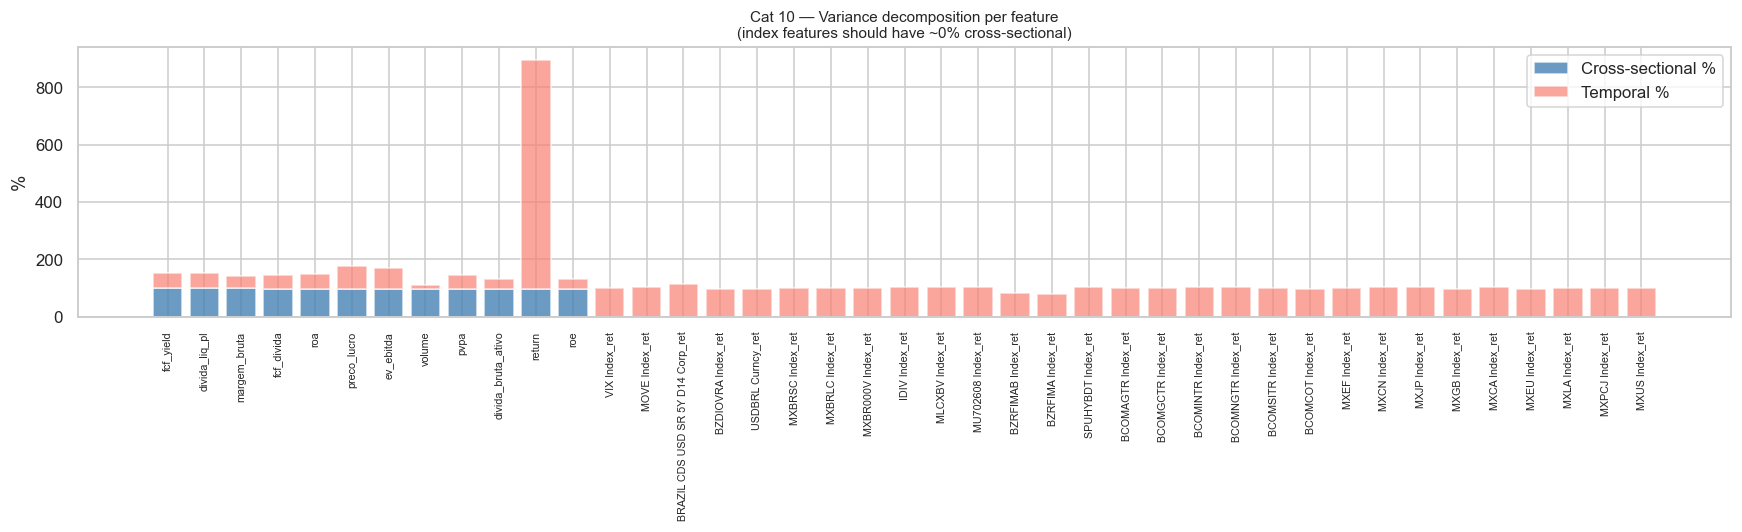


Features with essentially zero cross-sectional variance (cs_frac_pct < 0.1%):


,feature,cs_frac_pct,ts_frac_pct
12,VIX Index_ret,0.0,99.19
13,MOVE Index_ret,0.0,102.69
14,BRAZIL CDS USD SR 5Y D14 Corp_ret,0.0,115.49
15,BZDIOVRA Index_ret,0.0,98.26
16,USDBRL Curncy_ret,0.0,96.07
17,MXBRSC Index_ret,0.0,100.95
18,MXBRLC Index_ret,0.0,99.85
19,MXBR000V Index_ret,0.0,98.79
20,IDIV Index_ret,0.0,101.89
21,MLCXBV Index_ret,0.0,102.22


In [15]:
# ── Cat 10: Cross-sectional vs temporal variance decomposition ────────────────
# For each feature:
#   cross-sectional variance = mean over dates of Var_tickers(feature | date)
#   temporal variance        = mean over tickers of Var_dates(feature | ticker)
# We use train period and a random sample for memory efficiency.

SAMPLE_DATES    = train_x["date"].unique()
SAMPLE_TICKERS  = train_x["ticker"].unique()

# Limit sample for speed
rng = np.random.default_rng(42)
if len(SAMPLE_DATES) > 1000:
    SAMPLE_DATES   = rng.choice(SAMPLE_DATES,   size=1000, replace=False)
if len(SAMPLE_TICKERS) > 500:
    SAMPLE_TICKERS = rng.choice(SAMPLE_TICKERS, size=500,  replace=False)

sub = train_x[
    train_x["date"].isin(SAMPLE_DATES) &
    train_x["ticker"].isin(SAMPLE_TICKERS)
][["date", "ticker"] + FEATURE_COLS].copy()

var_rows = []
for col in FEATURE_COLS:
    # Cross-sectional: variance across tickers for each date, then average
    cs_var = sub.groupby("date")[col].var().mean()
    # Temporal: variance across dates for each ticker, then average
    ts_var = sub.groupby("ticker")[col].var().mean()
    total_var = sub[col].var()

    var_rows.append(dict(
        feature     = col,
        total_var   = round(total_var, 5),
        cs_var      = round(cs_var, 5),
        ts_var      = round(ts_var, 5),
        cs_frac_pct = round(100 * cs_var / total_var, 2) if total_var > 0 else 0,
        ts_frac_pct = round(100 * ts_var / total_var, 2) if total_var > 0 else 0,
    ))

var_df = pd.DataFrame(var_rows).sort_values("cs_frac_pct", ascending=False)
print("=== Variance Decomposition (train sample) ===")
print("cs_frac_pct = % of total variance that is cross-sectional (useful for ranking stocks on a given day)")
print()
display(var_df)

# Visual: bar chart
fig, ax = plt.subplots(figsize=(16, 5))
x_idx = range(len(var_df))
ax.bar(x_idx, var_df["cs_frac_pct"], label="Cross-sectional %", color="steelblue", alpha=0.8)
ax.bar(x_idx, var_df["ts_frac_pct"], bottom=var_df["cs_frac_pct"],
       label="Temporal %", color="salmon", alpha=0.7)
ax.set_xticks(list(x_idx))
ax.set_xticklabels(var_df["feature"], rotation=90, fontsize=7)
ax.set_title("Cat 10 — Variance decomposition per feature\n(index features should have ~0% cross-sectional)", fontsize=10)
ax.set_ylabel("%"); ax.legend()
plt.tight_layout(); plt.show()

print("\nFeatures with essentially zero cross-sectional variance (cs_frac_pct < 0.1%):")
display(var_df[var_df["cs_frac_pct"] < 0.1][["feature","cs_frac_pct","ts_frac_pct"]])

---
## Cat 11 — Esparsidade do Painel

O modelo requer ao menos 256 dias de histórico para produzir embeddings significativos. 
Tickers com histórico curto ou esparso inflam o dataset com observações de baixa qualidade.

**Diagnóstico**: distribuição de `n_days_per_ticker`, % de tickers abaixo dos limiares do modelo,
e mapa de cobertura por (ano × ticker) para visualizar a esparsidade estrutural do painel.

=== Panel Sparsity ===
Total tickers: 956
  <   64 days:  114 tickers (11.9%)
  <  128 days:  156 tickers (16.3%)
  <  256 days:  204 tickers (21.3%)
  <  512 days:  297 tickers (31.1%)
  < 1024 days:  408 tickers (42.7%)
  < 2048 days:  620 tickers (64.9%)

  Median: 1236 days
  Mean  : 1819 days


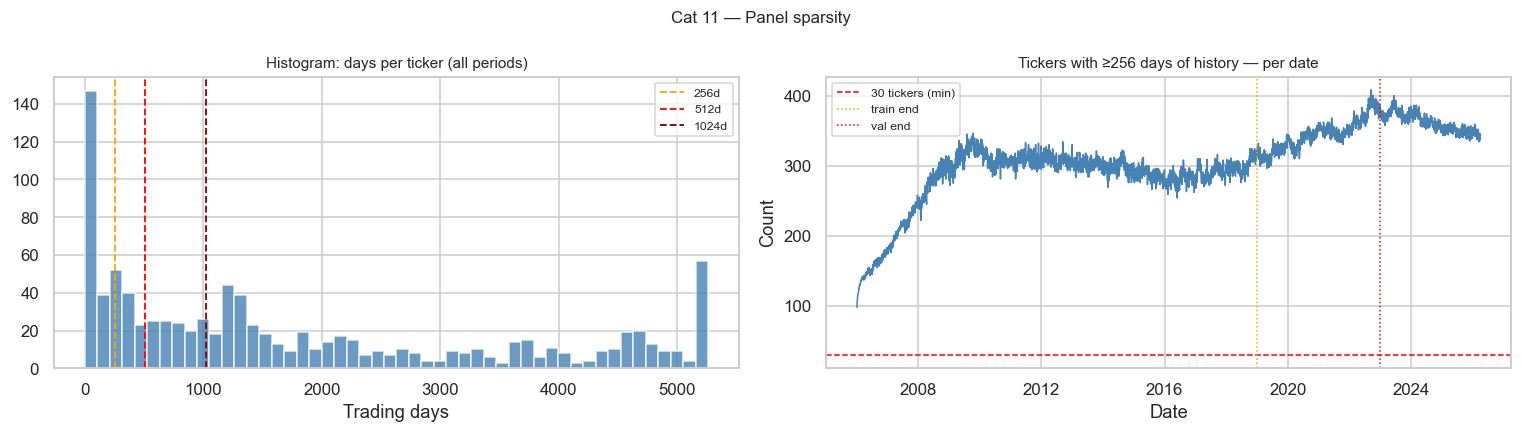


--- Coverage heatmap (top 100 tickers by total days) ---


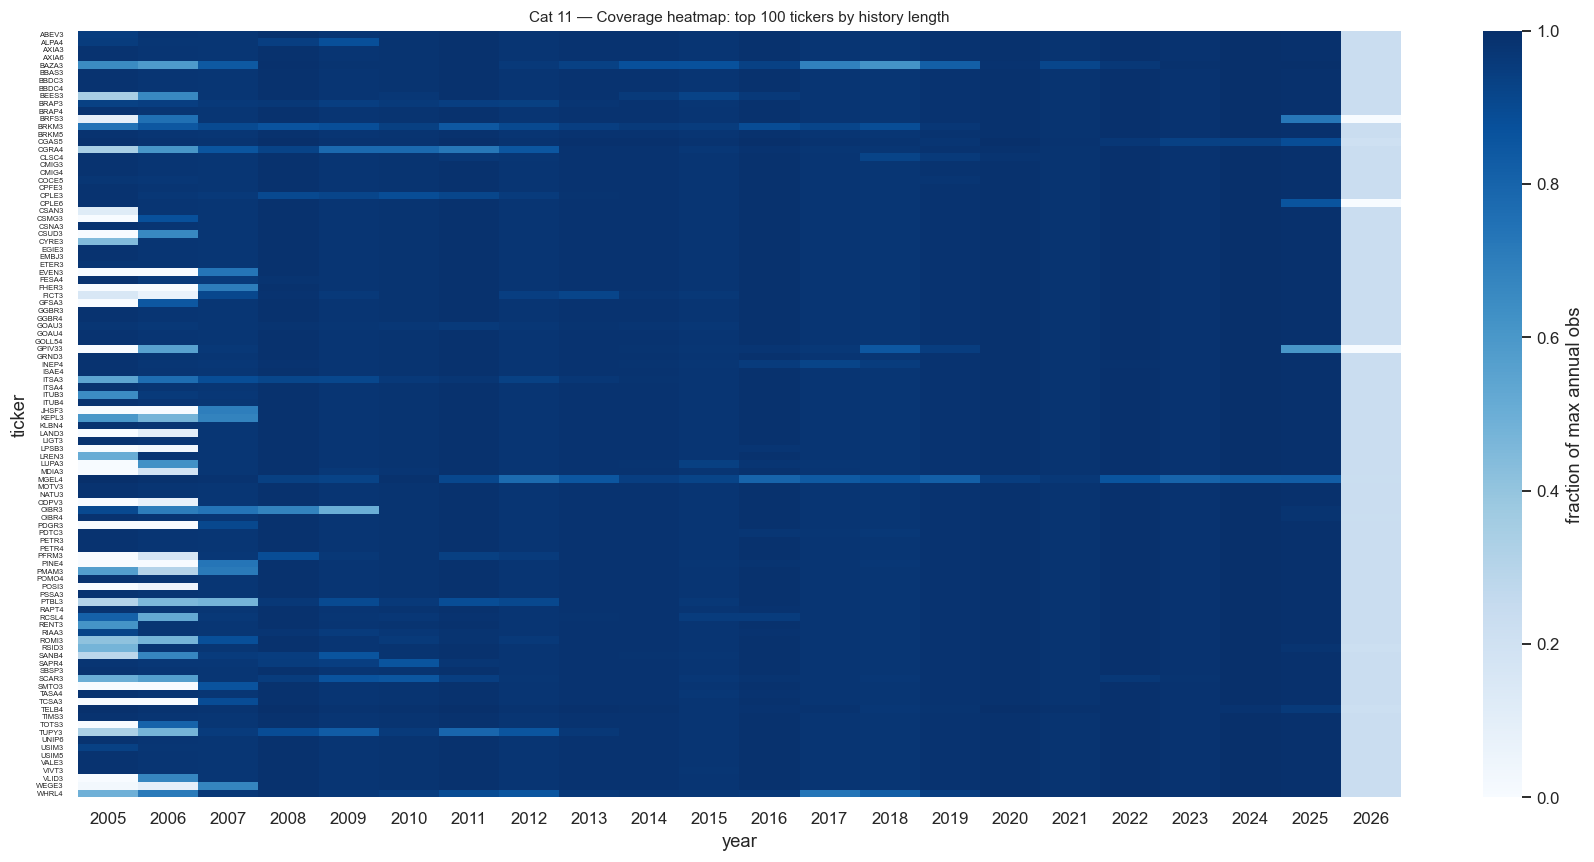

In [16]:
# ── Cat 11: Panel sparsity ────────────────────────────────────────────────────
days_per_ticker = x_ts.groupby("ticker")["date"].nunique().sort_values()
total_tickers = len(days_per_ticker)

thresholds = [64, 128, 256, 512, 1024, 2048]
print("=== Panel Sparsity ===")
print(f"Total tickers: {total_tickers}")
for t in thresholds:
    n = (days_per_ticker < t).sum()
    print(f"  < {t:4d} days: {n:4d} tickers ({100*n/total_tickers:.1f}%)")

print(f"\n  Median: {days_per_ticker.median():.0f} days")
print(f"  Mean  : {days_per_ticker.mean():.0f} days")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(days_per_ticker, bins=50, color="steelblue", alpha=0.8, edgecolor="white")
for t, col in [(256, "orange"), (512, "red"), (1024, "darkred")]:
    axes[0].axvline(t, color=col, linestyle="--", linewidth=1.2, label=f"{t}d")
axes[0].set_title("Histogram: days per ticker (all periods)", fontsize=10)
axes[0].set_xlabel("Trading days"); axes[0].legend(fontsize=8)

# Dates with >= 30 eligible tickers (256+ days history)
x_ts_sorted = x_ts.sort_values(["ticker", "date"])
x_ts_sorted["cum_days"] = x_ts_sorted.groupby("ticker").cumcount() + 1
eligible_per_date = (
    x_ts_sorted[x_ts_sorted["cum_days"] >= 256]
    .groupby("date")["ticker"].nunique()
)
axes[1].plot(eligible_per_date.index, eligible_per_date.values, color="steelblue", linewidth=1)
axes[1].axhline(30, color="red", linestyle="--", linewidth=1, label="30 tickers (min)")
for ts, label, col in [(TRAIN_END_TS,"train end","orange"), (VAL_END_TS,"val end","red")]:
    axes[1].axvline(ts, color=col, linestyle=":", linewidth=1, label=label)
axes[1].set_title("Tickers with ≥256 days of history — per date", fontsize=10)
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Count"); axes[1].legend(fontsize=8)

plt.suptitle("Cat 11 — Panel sparsity", fontsize=11)
plt.tight_layout(); plt.show()

# Coverage heatmap (subset of tickers)
print("\n--- Coverage heatmap (top 100 tickers by total days) ---")
top_tickers = days_per_ticker.nlargest(100).index.tolist()
pivot = (
    x_ts[x_ts["ticker"].isin(top_tickers)]
    .assign(year=lambda df: df["date"].dt.year)
    .groupby(["ticker", "year"])["date"].count()
    .unstack(fill_value=0)
)
pivot_norm = pivot.div(pivot.max(axis=1), axis=0)  # normalize by ticker's max

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot_norm, cmap="Blues", ax=ax, linewidths=0, xticklabels=True,
            yticklabels=True, cbar_kws={"label": "fraction of max annual obs"})
ax.set_title("Cat 11 — Coverage heatmap: top 100 tickers by history length", fontsize=10)
ax.tick_params(axis="y", labelsize=5)
plt.tight_layout(); plt.show()

---
## Cat 12 — Qualidade da Integração de Dados

Problemas silenciosos que podem surgir na integração de múltiplas fontes: 
duplicatas de (date, ticker), baixo match-rate de tickers entre fontes, e gaps de preço (suspensões).

**Diagnóstico**: check de duplicatas em cada parquet, taxa de match entre sources, e distribuição de gaps de preços por ticker.

In [17]:
# ── Cat 12: Data integration quality ─────────────────────────────────────────
# A: Duplicate (date, ticker) check across all parquets
check_files = {
    "prices"          : CLEANED  / "prices.parquet",
    "x_ts"            : PARQUETS / "x_ts.parquet",
    "fundamentals_ffill": FEATURES / "fundamentals_ffill.parquet",
    "returns"         : FEATURES / "returns.parquet",
    "fcf_divida"      : FEATURES / "fcf_divida_ffill.parquet",
    "fcf_yield"       : FEATURES / "fcf_yield.parquet",
}

print("=== Duplicate (date, ticker) check ===")
dup_rows = []
for name, path in check_files.items():
    df = pd.read_parquet(path, columns=["date", "ticker"])
    n_total = len(df)
    n_dup = df.duplicated(subset=["date", "ticker"]).sum()
    dup_rows.append({"file": name, "n_rows": n_total, "n_duplicates": int(n_dup),
                     "dup_rate_pct": round(100 * n_dup / n_total, 4)})

display(pd.DataFrame(dup_rows))

# B: Ticker match rate between prices and cleaned fundamentals
price_tickers = set(prices["ticker"].unique())
print("\n=== Ticker coverage: prices universe vs each cleaned/{feature}.parquet ===")
match_rows = []
for name, (_, col) in FUNDAMENTAL_FILES.items():
    path = CLEANED / f"{name}.parquet"
    if path.exists():
        df = pd.read_parquet(path, columns=["ticker"])
        feat_tickers = set(df["ticker"].unique())
        matched = feat_tickers & price_tickers
        match_rows.append({
            "feature"         : name,
            "feat_tickers"    : len(feat_tickers),
            "price_tickers"   : len(price_tickers),
            "matched"         : len(matched),
            "match_rate_pct"  : round(100 * len(matched) / len(price_tickers), 2),
            "only_in_feat"    : len(feat_tickers - price_tickers),
            "only_in_prices"  : len(price_tickers - feat_tickers),
        })
display(pd.DataFrame(match_rows))

# C: Price gaps per ticker (consecutive trading days)
p_sorted = prices.sort_values(["ticker", "date"])
p_sorted["prev_date"] = p_sorted.groupby("ticker")["date"].shift(1)
p_sorted["gap_days"]  = (p_sorted["date"] - p_sorted["prev_date"]).dt.days

large_gaps = p_sorted[p_sorted["gap_days"] > 7].copy()  # >1 week gap
print(f"\n=== Price gaps > 7 calendar days ===")
print(f"Total gap events: {len(large_gaps)}")
print(f"Tickers affected: {large_gaps['ticker'].nunique()}")
print(f"\nTop 20 largest gaps:")
display(
    large_gaps.nlargest(20, "gap_days")[["date", "ticker", "prev_date", "gap_days"]]
    .reset_index(drop=True)
)

# D: x_ts vs x_static ticker alignment
ts_tickers     = set(x_ts["ticker"].unique())
static_tickers = set(x_static["ticker"].unique())
print(f"\n=== x_ts vs x_static ticker alignment ===")
print(f"  x_ts tickers     : {len(ts_tickers)}")
print(f"  x_static tickers : {len(static_tickers)}")
print(f"  In x_ts not in x_static: {len(ts_tickers - static_tickers)}")
print(f"  In x_static not in x_ts: {len(static_tickers - ts_tickers)}")
if ts_tickers - static_tickers:
    print("  Missing from x_static:", sorted(ts_tickers - static_tickers)[:20])

=== Duplicate (date, ticker) check ===


,file,n_rows,n_duplicates,dup_rate_pct
0,prices,1739547,0,0.0
1,x_ts,1738572,0,0.0
2,fundamentals_ffill,1739547,0,0.0
3,returns,1738572,0,0.0
4,fcf_divida,1739547,0,0.0
5,fcf_yield,1739547,0,0.0



=== Ticker coverage: prices universe vs each cleaned/{feature}.parquet ===


,feature,feat_tickers,price_tickers,matched,match_rate_pct,only_in_feat,only_in_prices
0,roa,958,975,958,98.26,0,17
1,roe,896,975,896,91.90,0,79
2,margem_bruta,933,975,933,95.69,0,42
3,divida_bruta_ativo,874,975,874,89.64,0,101
4,divida_liq_pl,874,975,874,89.64,0,101
5,pvpa,968,975,968,99.28,0,7
6,ev_ebitda,861,975,861,88.31,0,114
7,preco_lucro,955,975,955,97.95,0,20
8,volume,975,975,975,100.00,0,0



=== Price gaps > 7 calendar days ===
Total gap events: 33702
Tickers affected: 559

Top 20 largest gaps:


,date,ticker,prev_date,gap_days
0,2024-12-23,TKNO3,2012-07-17,4542.0
1,2016-08-17,MRSA5B,2005-06-17,4079.0
2,2017-05-17,TAEE3,2007-04-30,3670.0
3,2014-10-02,MRSA6B,2005-06-27,3384.0
4,2017-11-16,AFLU5,2008-10-08,3326.0
5,2020-08-19,SNSY6,2012-02-09,3114.0
6,2020-10-30,CEPE3,2012-09-21,2961.0
7,2018-10-26,CALI3,2011-10-20,2563.0
8,2015-07-27,APTI4,2008-08-29,2523.0
9,2016-05-24,PTPA3,2009-08-14,2475.0



=== x_ts vs x_static ticker alignment ===
  x_ts tickers     : 956
  x_static tickers : 956
  In x_ts not in x_static: 0
  In x_static not in x_ts: 0



---
## Sumário dos Diagnósticos

| # | Categoria | Status | Achado Principal |
|---|-----------|--------|-----------------|
| 1a | Winsorização com look-ahead | 🔴 | `02_clean_fundamentals.py` aplica `quantile(0.01/0.99)` sobre o dataset completo (sem filtro de treino). 3 / 9 features com shift >5%: `volume` (p99 +85%), `divida_bruta_ativo` (+84%), `roa` (+14%). |
| 1b | Bloomberg interpolação bidirecional | 🟡 | `03_clean_bloomberg.py` usa `interpolate(limit=3)` sem `limit_direction` — gap de 1 dia pode ser backward-filled. Empiricamente: 2 índices com 1 NaN cada, max_gap=1d. Risco presente, impacto negligível. |
| 2 | Staleness de fundamentais | 🟡 | `06_feature_fundamentals.py` usa `ffill()` sem limite de tempo. Mediana ~47 dias (normal). Casos críticos: `roe` max_stale=6 660 dias, 5,8% das obs >365d. 1 ticker com >80% stale >365d. |
| 3 | Outliers em retornos | 🟡 | `05_feature_returns.py` não winsoriza retornos. 0,639% das obs de treino com \|return\| > 5σ (6 851 eventos); máximo: CTMI3 = +6,97 (normalizado: ~139σ). Distribuição fortemente leptocúrtica. |
| 4 | Survivorship bias | 🟢 | **Não confirmado.** O pipeline carrega histórico completo da Economatica, incluindo tickers delistados/encerrados. Os 532 "exiting tickers" (54,6%) **estão** presentes no dataset até sua última observação — isso é o comportamento correto para um dataset histórico. Não há viés de sobrevivência estrutural. |
| 5 | Distribution shift | 🟡 | `08_assemble_x_ts.py` normaliza corretamente com stats do treino (sem leakage). O shift é uma propriedade real dos dados: ≥ 20 / 41 features com KS p < 0,01. `fcf_yield` mais deslocado (KS=0,223). Não é bug do pipeline; é sinal de instabilidade da distribuição. |
| 6 | Zero-fill contamination | 🔴 | Confirmado no `08_assemble_x_ts.py`: normalização z-score → `fillna(0.0)`. Zeros no espaço normalizado = **média do treino**. 100% dos zeros em fundamentais trimestrais são de origem NaN. Taxa: roa 11,9%, roe 16,3%, `fcf_divida` 32,5%, `fcf_yield` 30,1%. 18 tickers com >80% zeros. |
| 7 | Compostas (FCF Yield / FCF/Dívida) | 🟡 | `05b_feature_composite.py` aplica `_winsorize()` sobre dataset completo (sem split de treino) — **mesma estrutura de look-ahead da Cat 1a**. Porém impacto empírico negligível: bounds treino ≈ bounds full (diferença < 0,01). Problema principal é cobertura baixa no início (2005: ~18%). |
| 8 | ON/PN duplicatas | 🟡 | 262 empresas com >1 classe; 334 tickers extras. Correlações altas: VALE3/VALE5=0,966, PETR3/PETR4=0,963. Pipeline não filtra duplicatas — ambas as classes entram no treino. |
| 9 | Correlação / redundância | 🟡 | 26 pares com \|r\| ≥ 0,75 (todos entre índices, máx=0,9997). PCA: 90% da variância dos 29 índices em ~10 componentes. Pipeline usa os 29 índices brutos sem redução. |
| 10 | Variância cross-sectional | ⬜ | **Confirmado estruturalmente.** Todos os 29 índices Bloomberg têm cs_frac < 0,1% — variância puramente temporal, idêntica para todos os tickers no mesmo dia. As 12 features ticker-específicas têm cs_frac ~96–101%. `return` tem ts_frac=799% (alta volatilidade temporal) com cs_frac=96%. O modelo só pode diferenciar tickers cross-sectionalmente pelas 12 features específicas. |
| 11 | Esparsidade do painel | 🟢 | 956 tickers totais; 204 (21,3%) com <256 dias de histórico (abaixo do mínimo do modelo). Mediana=1 236 dias, média=1 819 dias — painel razoavelmente denso. Primeiro dia com ≥30 tickers elegíveis (≥256d): 2006-01-11. Mínimo histórico de tickers elegíveis por data: 98 (sempre acima do limiar de 30). |
| 12 | Qualidade da integração de dados | 🟢 | **Sem problemas críticos.** Zero duplicatas de (date, ticker) em todos os 6 parquets. Match rate de tickers fundamentais vs preços: 88,3%–100% (até 114 tickers só em preços, sem correspondência em fundamentais — esperado para ações sem cobertura analítica). 33 702 gaps de preço >7 dias em 559 tickers — maioria são períodos de suspensão/delisting. x_ts e x_static perfeitamente alinhados (956 tickers cada, 0 divergências). |

---
### Prioridade de correção (revisada após leitura do código)

| Prioridade | Categoria | Causa raiz no pipeline | Ação sugerida |
|---|---|---|---|
| 🔴 1 | Cat 6 — Zero-fill | `fillna(0.0)` após normalização em `08_assemble_x_ts.py` | Criar coluna de máscara de missingness ou imputar pela mediana do treino antes da normalização |
| 🔴 2 | Cat 1a — Look-ahead winsorização | `quantile()` sobre dataset completo em `02_clean_fundamentals.py` | Calcular bounds somente nos dados `date <= TRAIN_END` antes de clipar |
| 🟡 3 | Cat 7 — Look-ahead nas compostas | `_winsorize()` sobre dataset completo em `05b_feature_composite.py` | Mesma correção da Cat 1a |
| 🟡 4 | Cat 2 — Staleness extremo | `ffill()` sem limite em `06_feature_fundamentals.py` | Adicionar `limit=400` (aprox. 2 trimestres de folga) e marcar NaN além disso |
| 🟡 5 | Cat 9 — Redundância de índices | Pipeline usa 29 índices brutos sem redução | Substituir por PCA (5–10 componentes) dos 29 índices |
| 🟡 6 | Cat 8 — ON/PN duplicatas | Sem filtro no pipeline | Selecionar ação mais líquida por empresa (maior volume médio) |
| 🟢 7 | Cat 3 — Outliers em retornos | `05_feature_returns.py` sem winsorização | Winsorizar log-returns no espaço bruto (antes da normalização) com bounds do treino |
